In [85]:
import torch
import matplotlib.pyplot as plt

In [86]:
def true_function(x):
    """데이터 생성에 사용하는 실제 3차 다항함수."""

    return (
        5.0
        + 1.2 * x
        - 3.4 * x.pow(2)
        + 2.0 * x.pow(3)
    )
    

def sample_data(number_of_examples):
    """[-1, 1]에서 x를 추출하고 Gaussian noise를 더한다."""
    
    x = (
        torch.rand(
            number_of_examples,
            1,
            dtype=torch.float64
        ) * 2 - 1
    )
    
    noise = (
        torch.randn(
            number_of_examples,
            1,
            dtype=torch.float64,
        ) * 0.1
    )
    
    y = true_function(x) + noise

    return x, y


def polynomial_features(x, degree):
    """x를 [1, x, x², ..., xᵈ]로 변환한다."""

    return torch.cat(
        [
            x.pow(power)
            for power in range(degree + 1)
        ],
        dim=1,
    )

In [87]:
# Cell 3
# 적은 training data와 충분한 validation data를 만든다.
train_x, train_y = sample_data(
    number_of_examples=20,
)

validation_x, validation_y = sample_data(
    number_of_examples=200,
)

print("Training X shape:", train_x.shape)
print("Training y shape:", train_y.shape)

print("Validation X shape:", validation_x.shape)
print("Validation y shape:", validation_y.shape)

Training X shape: torch.Size([20, 1])
Training y shape: torch.Size([20, 1])
Validation X shape: torch.Size([200, 1])
Validation y shape: torch.Size([200, 1])


In [88]:
def fit_polynomial(degree):
    """주어진 degree의 다항회귀 모델을 최소제곱법으로 fitting한다."""
    
    train_features = polynomial_features(
        train_x,
        degree,
    )
    
    validation_features = polynomial_features(
        validation_x,
        degree,
    )
    
    # train_features @ weights ≈ train_y를 만족하는
    # least-squares solution(최소제곱해)를 계산한다.
    weights = torch.linalg.lstsq(
        train_features,
        train_y,
    ).solution

    train_predictions = (
        train_features @ weights
    )

    validation_predictions = (
        validation_features @ weights
    )
    
    training_error = (
        train_predictions - train_y
    ).pow(2).mean()
    
    validation_error = (
        validation_predictions - validation_y
    ).pow(2).mean()
    

    return {
        "degree": degree,
        "weights": weights,
        "training_error": training_error,
        "validation_error": validation_error,
    }
    
    
degrees = [1, 3, 5, 10, 15, 20]

results = [
    fit_polynomial(degree)
    for degree in degrees
]

for result in results:
    print(
        f"Degree {result['degree']:2d} "
        f"| train={result['training_error'].item():.6f} "
        f"| validation={result['validation_error'].item():.6f}"
    )

Degree  1 | train=0.812150 | validation=1.207216
Degree  3 | train=0.005752 | validation=0.017974
Degree  5 | train=0.004638 | validation=0.017803
Degree 10 | train=0.001552 | validation=1.765208
Degree 15 | train=0.000751 | validation=67139.725471
Degree 20 | train=0.000000 | validation=520582967.560811


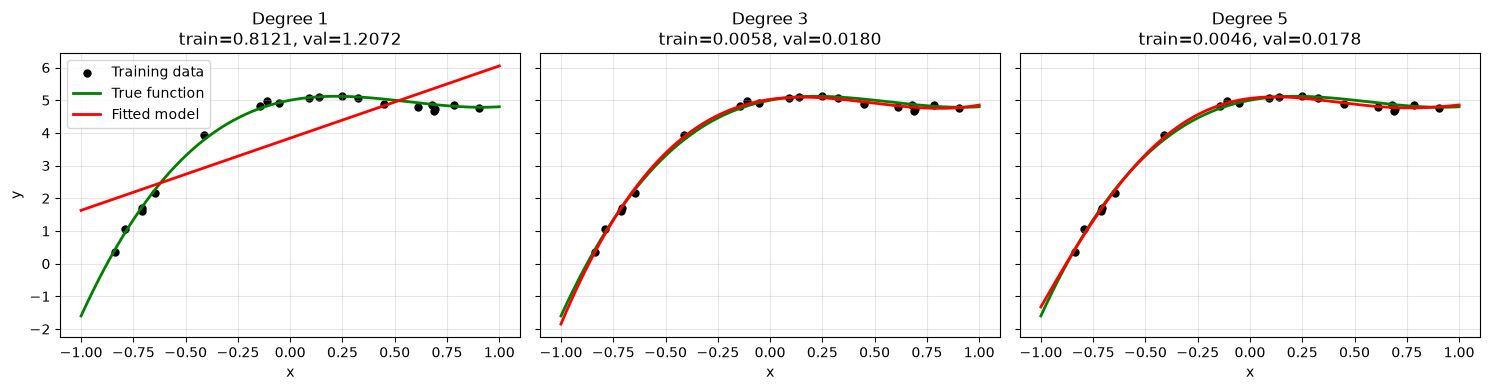

In [89]:
# Cell 6
plot_x = torch.linspace(
    -1,
    1,
    500,
    dtype=torch.float64,
).reshape(-1, 1)

true_plot_y = true_function(plot_x)

figure, axes = plt.subplots(
    1,
    3,
    figsize=(15, 4),
    sharey=True,
)

for axis, result in zip(axes, results):
    degree = result["degree"]

    predicted_plot_y = (
        polynomial_features(plot_x, degree)
        @ result["weights"]
    )

    axis.scatter(
        train_x.numpy(),
        train_y.numpy(),
        color="black",
        s=25,
        label="Training data",
    )

    axis.plot(
        plot_x.numpy(),
        true_plot_y.numpy(),
        color="green",
        linewidth=2,
        label="True function",
    )

    axis.plot(
        plot_x.numpy(),
        predicted_plot_y.detach().numpy(),
        color="red",
        linewidth=2,
        label="Fitted model",
    )

    axis.set_title(
        f"Degree {degree}\n"
        f"train={result['training_error'].item():.4f}, "
        f"val={result['validation_error'].item():.4f}"
    )

    axis.set_xlabel("x")
    axis.grid(alpha=0.3)

axes[0].set_ylabel("y")
axes[0].legend()

plt.tight_layout()
plt.show()